# ***Solución del Parcial 1 — Autenticación de Billetes***

**Integrantes:**

1.   Santiago Arango / sarangoh@javerianacali.edu.co
2.   Jhon Rios / jdriosa@javerianacali.edu.co
3.   Jhon Deiby Mejias / jhon0303@javerianacali.edu.co

**Fecha:** 23/02/2026

---

## **Punto 1: Análisis Exploratorio de Datos (EDA)**



**1. Cargar mi dataset.** El dataset por el profe 
en formato `.csv` 

| Característica | Descripción |
|---|---|
| `variance` | Varianza de la imagen wavelet |
| `skewness` | Asimetría de la imagen wavelet |
| `curtosis` | Curtosis de la imagen wavelet |
| `entropy` | Entropía de la imagen |
| `class` | **0** = Billete Falso / **1** = Billete Verdadero |


## Importar librerias necesarias

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

**3. Cargar y analizar mi dataset:** 

In [23]:
Billetes = pd.read_csv("data_Parcial_Billetes.csv")
print(type(Billetes))

<class 'pandas.DataFrame'>


Analizar primeras 10 filas


In [24]:
print(Billetes.head(10))

   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661  -2.80730 -0.44699      0
1   4.54590    8.1674  -2.45860 -1.46210      0
2   3.86600   -2.6383   1.92420  0.10645      0
3   3.45660    9.5228  -4.01120 -3.59440      0
4   0.32924   -4.4552   4.57180 -0.98880      0
5   4.36840    9.6718  -3.96060 -3.16250      0
6   3.59120    3.0129   0.72888  0.56421      0
7   2.09220   -6.8100   8.46360 -0.60216      0
8   3.20320    5.7588  -0.75345 -0.61251      0
9   1.53560    9.1772  -2.27180 -0.73535      0


**4. Verificar atributos del DataFrame:** 


In [25]:
print(Billetes.shape)

(1372, 5)


Por otro lado, puedo usar el atributo `info` que me permite conocer a más detalle cada columna y una descripción más clara de mis datos:


In [26]:
Billetes.info()

<class 'pandas.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [27]:
Billetes.describe()

,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [28]:
Billetes["class"].value_counts().to_frame()

,count
class,
0,762
1,610


**5. Realizar un "pair plot"**: 
* `"o"` círculos
* `"s"` cuadrados
.


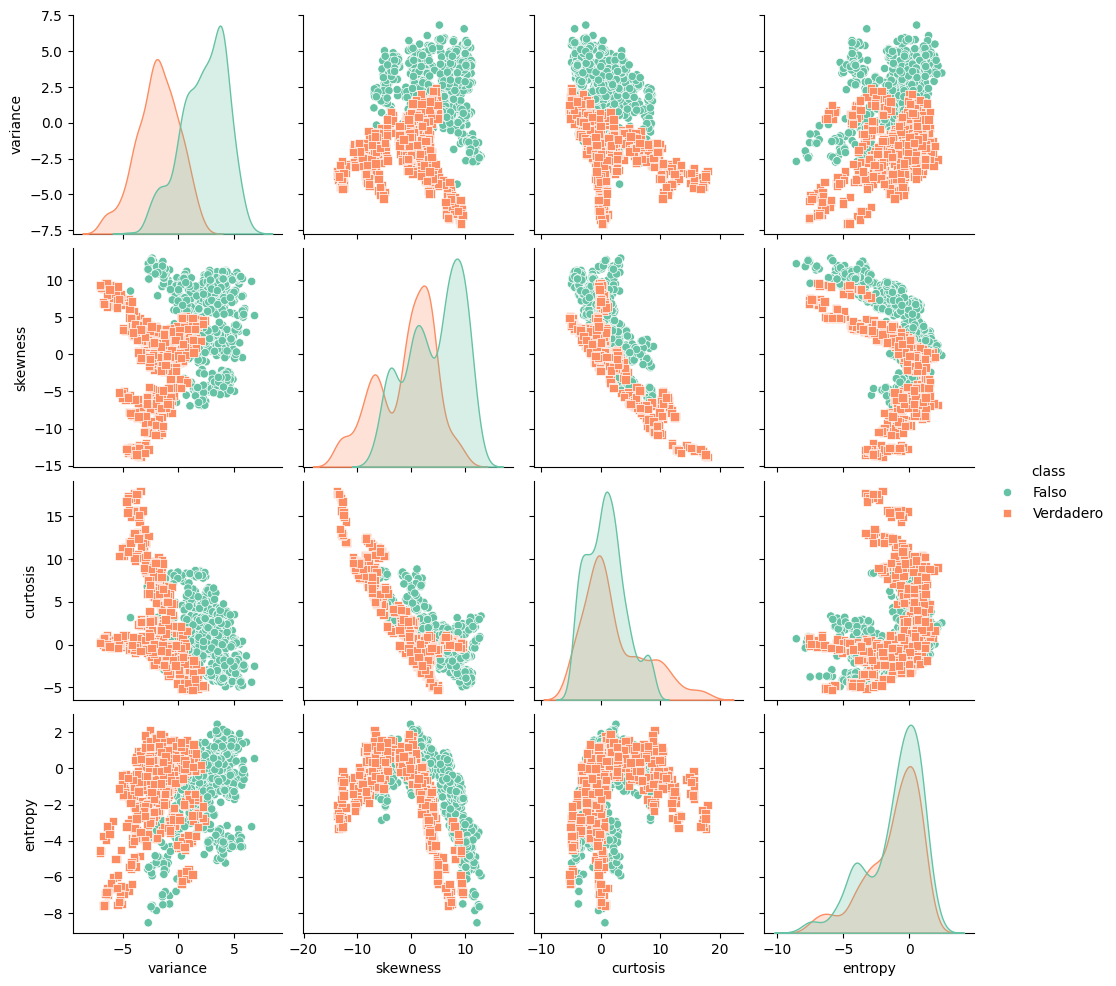

In [29]:
import seaborn as sns

# Crear una copia del dataset con etiquetas textuales para las clases
Billetes_plot = Billetes.copy()
Billetes_plot["class"] = Billetes_plot["class"].map({0: "Falso", 1: "Verdadero"})

sns.pairplot(Billetes_plot, hue="class", markers=["o", "s"], palette="Set2")
plt.show()

**6. Realizar un histograma de mis características globales:** 

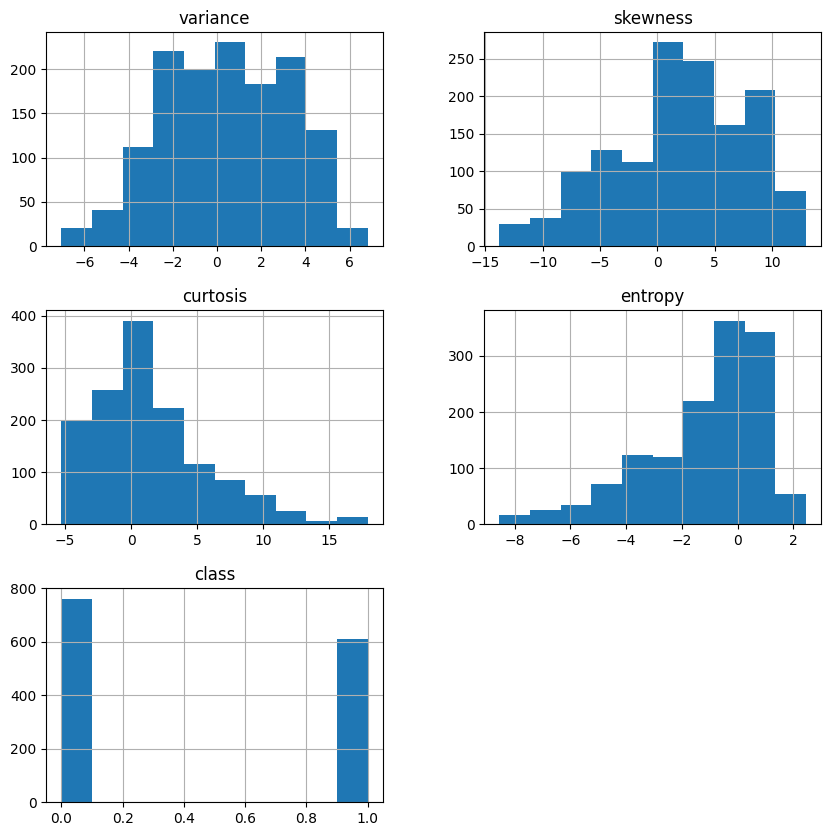

In [30]:
Billetes.hist(figsize=(10, 10), bins=10)
plt.show()

Creamos el histograma de cada una de las características para cada una de las clases:


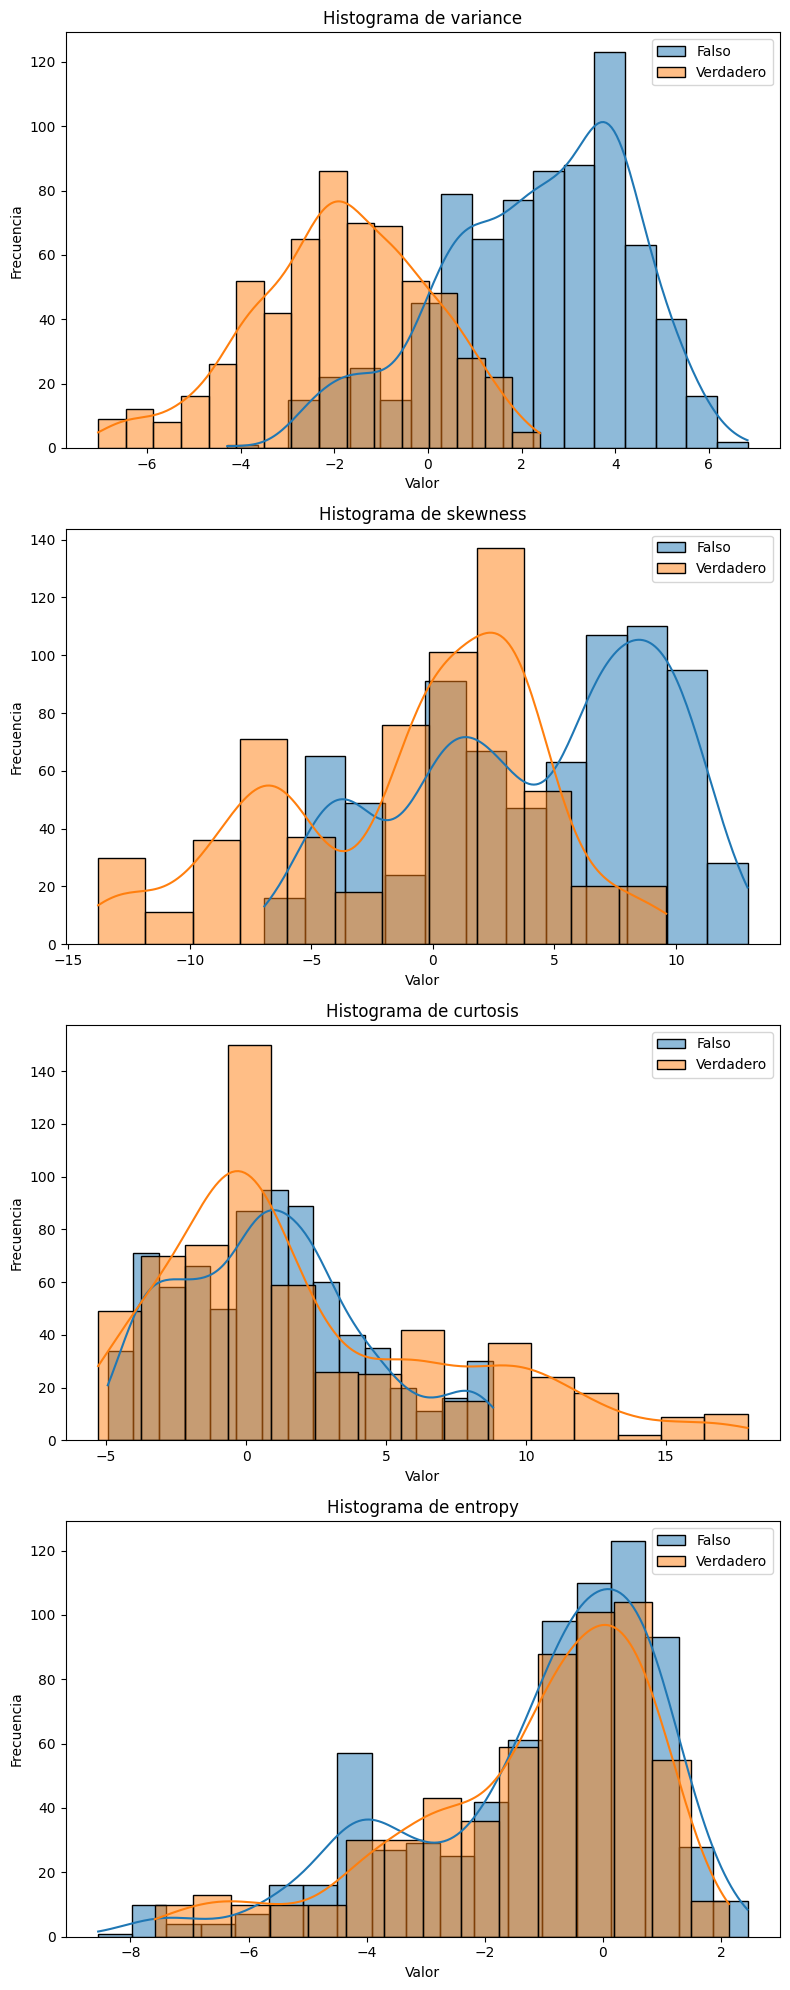

In [31]:
# Crear las figuras y los subplots
fig, axes = plt.subplots(4, 1, figsize=(8, 20))

# Lista de características y clases
features = ['variance', 'skewness', 'curtosis', 'entropy']
classes = Billetes['class'].unique()

# Iterar sobre las características y crear histogramas para cada clase
for i, feature in enumerate(features):
    for cls in classes:
        label = 'Falso' if cls == 0 else 'Verdadero'
        sns.histplot(Billetes[Billetes['class'] == cls][feature], ax=axes[i], label=label, kde=True)
    axes[i].set_title(f'Histograma de {feature}')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()

# Ajustar el espaciado entre subplots
plt.tight_layout()

# Mostrar las figuras
plt.show()

Matriz de correlación:


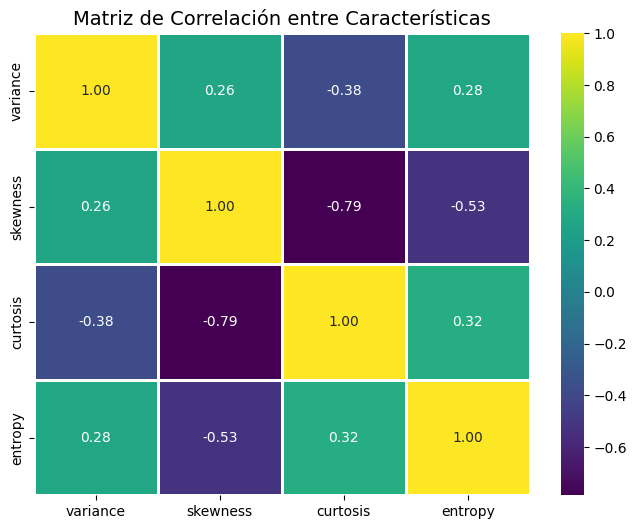

In [32]:
# Seleccionar solo las columnas numéricas para la matriz de correlación
numeric_cols = ['variance', 'skewness', 'curtosis', 'entropy']
numeric_data = Billetes[numeric_cols]

# Calcular la matriz de correlación
correlation_matrix = numeric_data.corr()

# Crear una figura y un eje (subplot) utilizando seaborn
plt.figure(figsize=(8, 6))

# Cambiar el colormap a 'viridis'
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt='.2f', linewidths=1, linecolor='white')

# Añadir título
plt.title('Matriz de Correlación entre Características', fontsize=14)

# Mostrar la matriz de correlación
plt.show()

### Conclusión 

Con base en el análisis realizado las dos mejores caracteristicas para la separabilidad de las clases son:

-Variance
-Skewness

Esto se debe a ver la grafica de los pairplot, ya que cuando coiniciden estas dos caracteristicas, se evidencia la mayor separabilidad de las clases. Ademas, al ver los histogramas, son las dos caracteristicas que tienen mayor forma de distribucion normal.



### Selección de características (ítem 2)

En función del EDA realizado, seleccionamos las dos características con mayor poder discriminativo: **`variance`** y **`skewness`**. A continuación generamos la matriz de características `X` y el vector `y` de targets (también mostramos `y` en formato bipolar como en el notebook C4 para uso posterior con Perceptron).

In [33]:
# Seleccionar dos características para mejor separabilidad
best_features = ['variance', 'skewness']

# Seleccionar índices y datos de las clases 0 y 1 usando el DataFrame Billetes
class_0_indices = Billetes[Billetes['class'] == 0].index
class_1_indices = Billetes[Billetes['class'] == 1].index

class_0_data = Billetes.loc[class_0_indices]
class_1_data = Billetes.loc[class_1_indices]

# Concatenar clases 0 y 1 y asegurar columna 'target' para compatibilidad con otras celdas
class_0_1_data = pd.concat([class_0_data, class_1_data]).reset_index(drop=True).copy()
class_0_1_data['target'] = class_0_1_data['class']

# Proyección de datos en las dos características seleccionadas
X = class_0_1_data[best_features].values

print("X shape:", X.shape)
print("Primeras filas de 10:\n", X[:10])


X shape: (1372, 2)
Primeras filas de 10:
 [[ 3.6216   8.6661 ]
 [ 4.5459   8.1674 ]
 [ 3.866   -2.6383 ]
 [ 3.4566   9.5228 ]
 [ 0.32924 -4.4552 ]
 [ 4.3684   9.6718 ]
 [ 3.5912   3.0129 ]
 [ 2.0922  -6.81   ]
 [ 3.2032   5.7588 ]
 [ 1.5356   9.1772 ]]


In [34]:
import matplotlib.pyplot as plt
import numpy as np

y = class_0_1_data['target'].values
y = np.where(y==0,-1,1)

print(y)

[-1 -1 -1 ...  1  1  1]


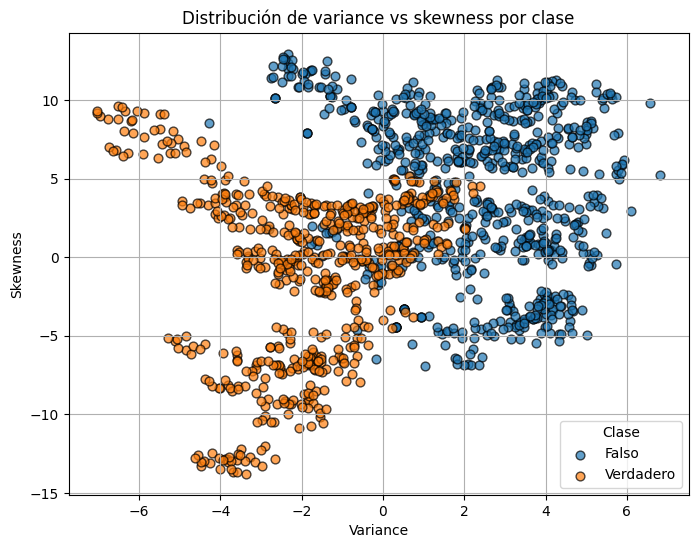

In [35]:
# Gráfico de dispersión de las dos características seleccionadas por clase
x_col, y_col = best_features

fig, ax = plt.subplots(figsize=(8, 6))
classes = {0: 'Falso', 1: 'Verdadero'}
colors = {0: 'C0', 1: 'C1'}

for cls_val, label in classes.items():
    subset = class_0_1_data[class_0_1_data['class'] == cls_val]
    ax.scatter(subset[x_col], subset[y_col], label=label, alpha=0.7, s=40, edgecolor='k', color=colors[cls_val])

ax.set_xlabel(x_col.capitalize())
ax.set_ylabel(y_col.capitalize())
ax.set_title(f'Distribución de {x_col} vs {y_col} por clase')
ax.legend(title='Clase')
ax.grid(True)
plt.show()

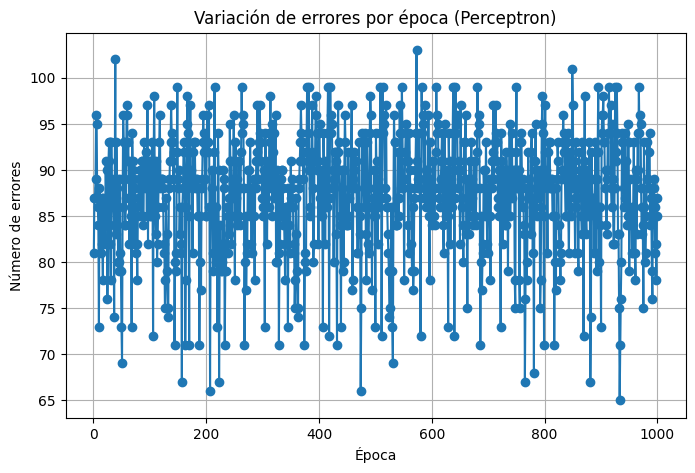

In [36]:
# Entrenar Perceptron con las dos características seleccionadas
import numpy as np

class Perceptron(object):
    """Clasificador Perceptron.

    Parámetros
    ------------
    eta : float
      Tasa de aprendizaje (entre 0.0 y 1.0)
    n_iter : int
      Número de iteraciones sobre el dataset.
    random_state : int
      Semilla del generador de números aleatorios para la inicialización del peso aleatorio.

    Atributos
    -----------
    w_ : Arreglo 1D
      Pesos antes del entrenamiento (Iniciales).
    errors_ : list
      Número de clasificaciones erróneas (actualizaciones) en cada época.

    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.errors_ = []
        self.w_historical = [self.w_.copy()]
        for _ in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                self.w_[1:] += update * xi
                self.w_[0] += update
                errors += int(update != 0.0)
            self.errors_.append(errors)
            self.w_historical.append(self.w_.copy())
        return self

    def net_input(self, X):
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, 0)

# Preparar etiquetas en formato 0/1 para esta implementación
y_binary = np.where(y == -1, 0, 1)

# Crear y ajustar el perceptron
ppn = Perceptron(eta=0.1, n_iter=1000, random_state=1)
ppn.fit(X, y_binary)

# Graficar errores por época
plt.figure(figsize=(8,5))
plt.plot(range(1, len(ppn.errors_)+1), ppn.errors_, marker='o')
plt.xlabel('Época')
plt.ylabel('Número de errores')
plt.title('Variación de errores por época (Perceptron)')
plt.grid(True)
plt.show()

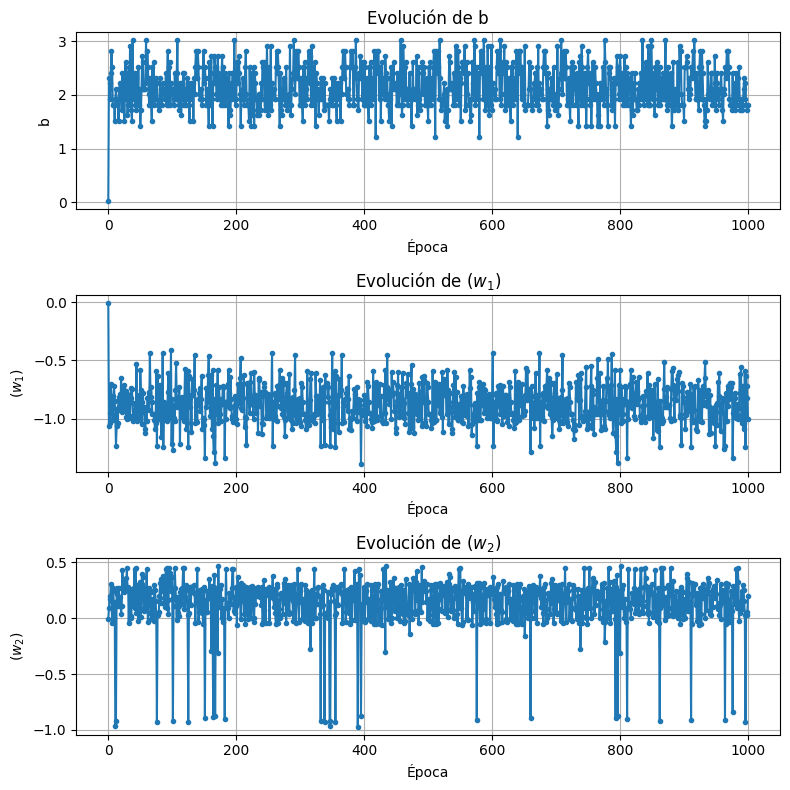

In [37]:
# 1) Variabilidad de hiperparámetros por época
epochs = np.arange(len(ppn.w_historical))

# Mostrar evolución individual de cada peso (bias, w1, w2)
labels = ['b', '($w_1$)', '($w_2$)']
fig, axs = plt.subplots(len(labels), 1, figsize=(8, 8))

for i, label in enumerate(labels):
    series = [w[i] for w in ppn.w_historical]
    axs[i].plot(epochs, series, marker='o', markersize=3)
    axs[i].set_title(f'Evolución de {label}')
    axs[i].set_xlabel('Época')
    axs[i].set_ylabel(label)
    axs[i].grid(True)

plt.tight_layout()
plt.show()





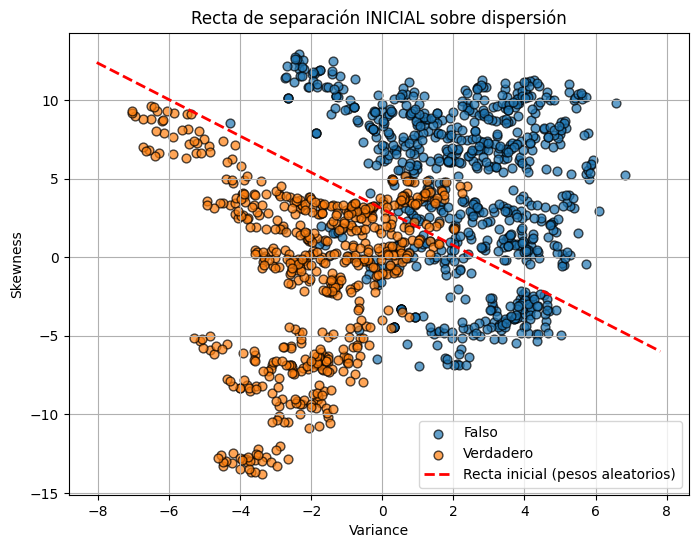

In [38]:
# 2) Recta de separación INICIAL sobre dispersión

# Calcular recta inicial (pesos aleatorios)
x_vals = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
b0_v  = ppn.w_historical[0][0]
w1_0  = ppn.w_historical[0][1]
w2_0  = ppn.w_historical[0][2]
w2_0_safe = w2_0 if abs(w2_0) > 1e-8 else 1e-8
y_vals_init = (-w1_0 * x_vals - b0_v) / w2_0_safe

fig, ax_init = plt.subplots(figsize=(8, 6))
for cls_val, label in classes.items():
    subset = class_0_1_data[class_0_1_data['class'] == cls_val]
    ax_init.scatter(subset[best_features[0]], subset[best_features[1]],
                    label=label, alpha=0.7, s=40, edgecolor='k', color=colors[cls_val])
ax_init.plot(x_vals, y_vals_init, 'r--', lw=2, label='Recta inicial (pesos aleatorios)')
ax_init.set_xlabel(best_features[0].capitalize())
ax_init.set_ylabel(best_features[1].capitalize())
ax_init.set_title('Recta de separación INICIAL sobre dispersión')
ax_init.legend()
ax_init.grid(True)
plt.show()


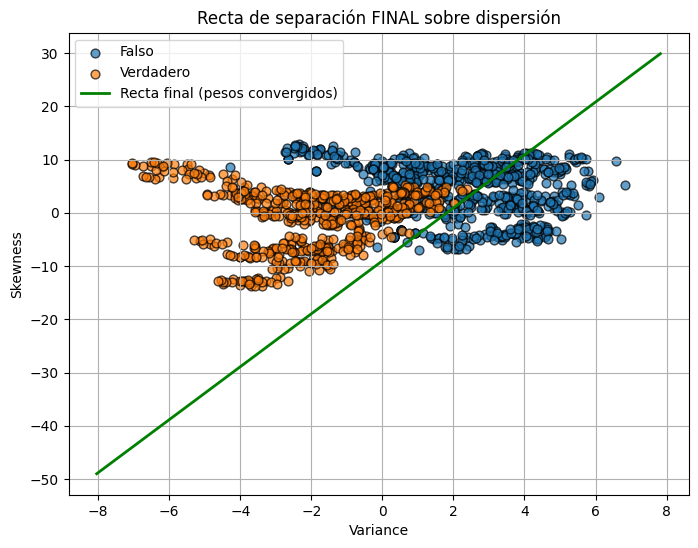

In [39]:
# 3) Recta de separación FINAL sobre dispersión

# Calcular recta final (pesos convergidos)
bf_v  = ppn.w_historical[-1][0]
w1_f  = ppn.w_historical[-1][1]
w2_f  = ppn.w_historical[-1][2]
w2_f_safe = w2_f if abs(w2_f) > 1e-8 else 1e-8
y_vals_final = (-w1_f * x_vals - bf_v) / w2_f_safe

fig, ax_final = plt.subplots(figsize=(8, 6))
for cls_val, label in classes.items():
    subset = class_0_1_data[class_0_1_data['class'] == cls_val]
    ax_final.scatter(subset[best_features[0]], subset[best_features[1]],
                     label=label, alpha=0.7, s=40, edgecolor='k', color=colors[cls_val])
ax_final.plot(x_vals, y_vals_final, 'g-', lw=2, label='Recta final (pesos convergidos)')
ax_final.set_xlabel(best_features[0].capitalize())
ax_final.set_ylabel(best_features[1].capitalize())
ax_final.set_title('Recta de separación FINAL sobre dispersión')
ax_final.legend()
ax_final.grid(True)
plt.show()



---

## Conclusiones — Parte 1 y 2: Perceptron con dos características (`variance`, `skewness`)



### Evolución de hiperparámetros
- Los pesos **b**, **w₁** y **w₂** presentan alta variabilidad a lo largo de las 1000 épocas y no se estabilizan, confirmando la ausencia de convergencia con solo dos features.

### Rectas de separación
- La **recta inicial** (pesos aleatorios) no separa las clases.  
- La **recta final** (pesos al final del entrenamiento) muestra una mejor orientación, pero sigue sin separar limpiamente ambas clases, lo que evidencia que el problema no es linealmente separable con estas dos características en 2D.



---

## EDA previo al Punto 6 — Análisis de las tres mejores características

Antes de entrenar el Perceptron con 3 features, se realiza un análisis exploratorio específico para **`variance`**, **`skewness`** y **`curtosis`**, siguiendo la misma metodología del EDA inicial.

Se presenta:
1. **Pair Plot** — relaciones entre pares de características, coloreado por clase.
2. **Histogramas por clase** — distribución de cada característica separada por clase.
3. **Distribución 3D** — dispersión en el espacio de las tres características simultáneamente.


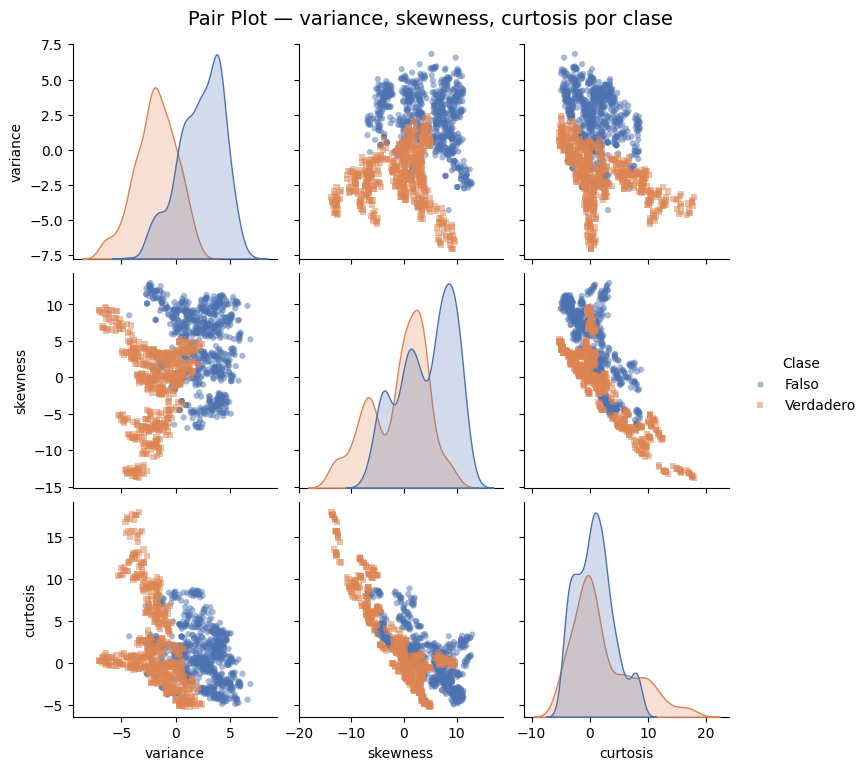

In [59]:

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EDA — PASO 1: Pair Plot de las 3 características
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import seaborn as sns
import matplotlib.pyplot as plt

features_eda3 = ['variance', 'skewness', 'curtosis']
clase_map     = {0: 'Falso', 1: 'Verdadero'}
palette_eda   = {'Falso': '#4C72B0', 'Verdadero': '#DD8452'}

# Preparar DataFrame con etiqueta textual
Billetes_3f = Billetes[features_eda3 + ['class']].copy()
Billetes_3f['Clase'] = Billetes_3f['class'].map(clase_map)

# Pair plot con marcadores diferenciados (igual que en el EDA principal)
sns.pairplot(
    Billetes_3f,
    hue='Clase',
    vars=features_eda3,
    markers=['o', 's'],
    palette=palette_eda,
    plot_kws=dict(alpha=0.5, edgecolors='none', s=20),
    diag_kind='kde'
)
plt.suptitle('Pair Plot — variance, skewness, curtosis por clase', y=1.02, fontsize=14)
plt.show()


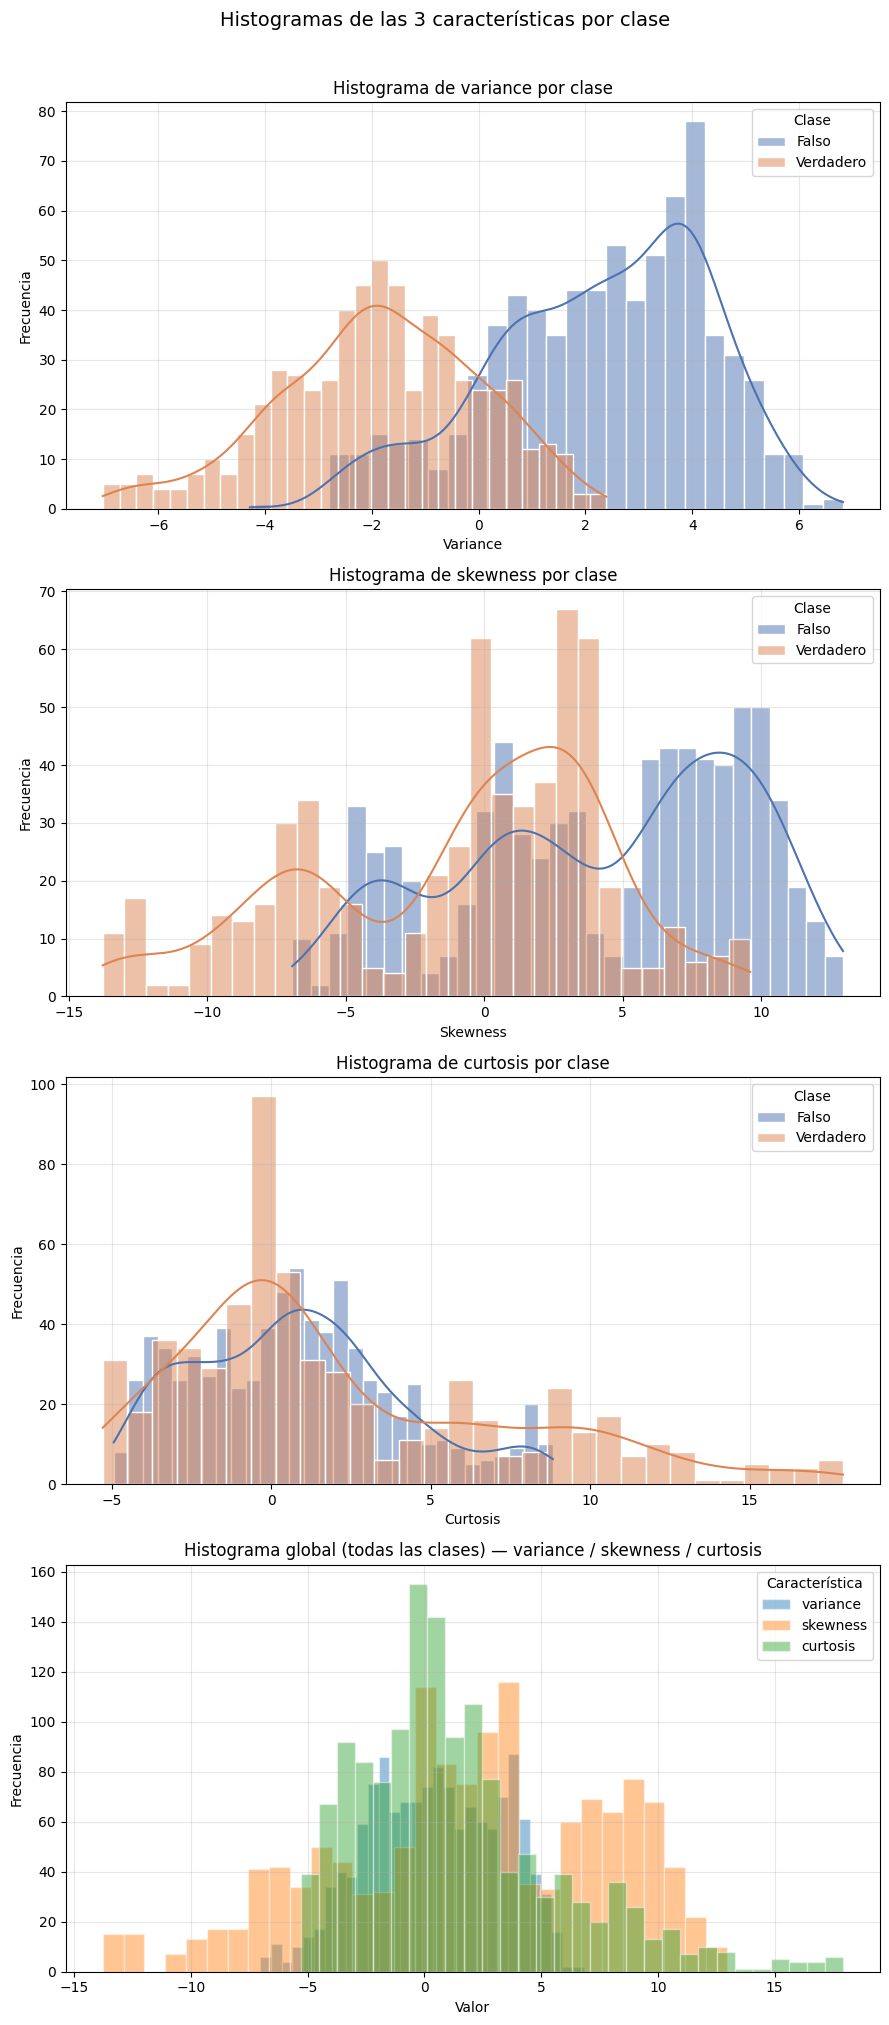

In [56]:

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EDA — PASO 2: Histogramas por clase para cada característica
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig, axes = plt.subplots(4, 1, figsize=(9, 20))

# Histogramas por clase con KDE (seaborn no requiere scipy)
for i, feat in enumerate(features_eda3):
    for cls_name in ['Falso', 'Verdadero']:
        data_cls = Billetes_3f[Billetes_3f['Clase'] == cls_name][feat]
        sns.histplot(data_cls, bins=30, kde=True, ax=axes[i],
                     label=cls_name, color=palette_eda[cls_name],
                     alpha=0.5, edgecolor='white')
    axes[i].set_title(f'Histograma de {feat} por clase', fontsize=12)
    axes[i].set_xlabel(feat.capitalize())
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(title='Clase')
    axes[i].grid(True, alpha=0.3)

# Histograma global (sin separar clases — referencia)
for feat in features_eda3:
    axes[3].hist(Billetes_3f[feat], bins=30, alpha=0.45, label=feat, edgecolor='white')
axes[3].set_title('Histograma global (todas las clases) — variance / skewness / curtosis', fontsize=12)
axes[3].set_xlabel('Valor')
axes[3].set_ylabel('Frecuencia')
axes[3].legend(title='Característica')
axes[3].grid(True, alpha=0.3)

plt.suptitle('Histogramas de las 3 características por clase', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [57]:

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EDA — PASO 3: Distribución 3D de las tres características
#              (Tres-Plot interactivo con Plotly)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import plotly.graph_objs as go

color_eda3 = {0: '#4C72B0', 1: '#DD8452'}
symbol_eda3 = {0: 'circle', 1: 'square'}

fig_eda3d = go.Figure()

for cls_val, cls_name in clase_map.items():
    mask3 = (Billetes['class'] == cls_val)
    fig_eda3d.add_trace(go.Scatter3d(
        x=Billetes.loc[mask3, 'variance'],
        y=Billetes.loc[mask3, 'skewness'],
        z=Billetes.loc[mask3, 'curtosis'],
        mode='markers',
        marker=dict(
            size=3,
            color=color_eda3[cls_val],
            symbol=symbol_eda3[cls_val],
            opacity=0.7,
            line=dict(width=0)
        ),
        name=cls_name
    ))

fig_eda3d.update_layout(
    scene=dict(
        xaxis=dict(title='Variance'),
        yaxis=dict(title='Skewness'),
        zaxis=dict(title='Curtosis'),
        bgcolor='white',
    ),
    title='Distribución 3D — variance vs skewness vs curtosis por clase',
    legend=dict(title='Clase', font=dict(size=12)),
    margin=dict(l=0, r=0, b=0, t=50)
)
fig_eda3d.show()


---

## Punto 6: 

En función del EDA realizado en el Punto 1, las tres características con mayor poder discriminativo entre clases son: **`variance`**, **`skewness`** y **`curtosis`**.

* **`variance`** y **`skewness`** muestran distribuciones claramente separadas por clase (histogramas y pairplot).
* **`curtosis`** añade un tercer eje de separabilidad visible en los histogramas por clase.
* **`entropy`** presenta mayor solapamiento entre clases, por lo que no se incluye.

A continuación se genera la matriz `X3` (3 Features) y el vector `y3` de targets.


In [40]:
# ── Punto 6.2 ── Selección de 3 características y generación de X3, y3 ──────
best_features_3 = ['variance', 'skewness', 'curtosis']

# Reutilizamos el DataFrame Billetes ya cargado
class_0_1_data_3 = Billetes.copy().reset_index(drop=True)
class_0_1_data_3['target'] = class_0_1_data_3['class']

X3 = class_0_1_data_3[best_features_3].values

y3_raw = class_0_1_data_3['target'].values
y3 = np.where(y3_raw == 0, 0, 1)          # 0 = Falso, 1 = Verdadero

print("X3 shape:", X3.shape)
print("y3 únicos:", np.unique(y3))
print("Primeras 5 filas:\n", X3[:5])


X3 shape: (1372, 3)
y3 únicos: [0 1]
Primeras 5 filas:
 [[ 3.6216   8.6661  -2.8073 ]
 [ 4.5459   8.1674  -2.4586 ]
 [ 3.866   -2.6383   1.9242 ]
 [ 3.4566   9.5228  -4.0112 ]
 [ 0.32924 -4.4552   4.5718 ]]


### 6.3 Gráfico de dispersión 3D de las tres características seleccionadas


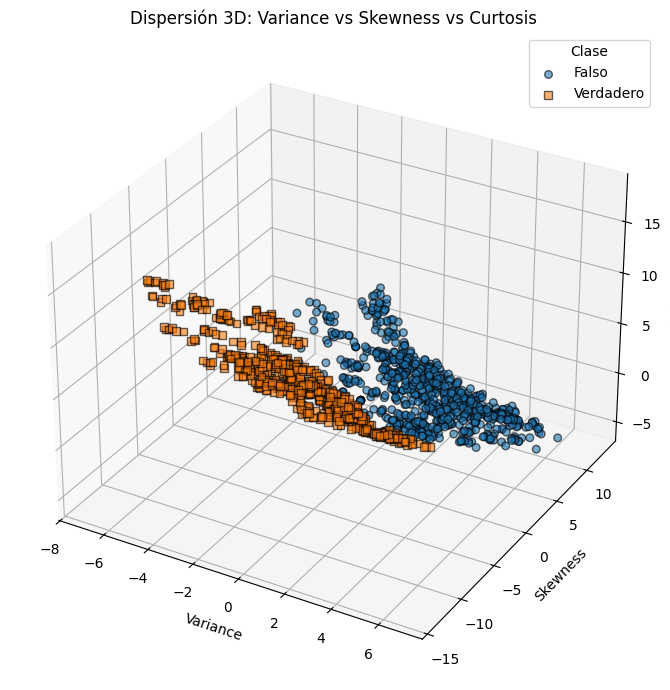

In [41]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

class_labels_3 = {0: 'Falso', 1: 'Verdadero'}
colors_3 = {0: 'C0', 1: 'C1'}
markers_3 = {0: 'o', 1: 's'}

fig3d = plt.figure(figsize=(9, 7))
ax3d = fig3d.add_subplot(111, projection='3d')

for cls_val, lbl in class_labels_3.items():
    mask = (y3 == cls_val)
    ax3d.scatter(X3[mask, 0], X3[mask, 1], X3[mask, 2],
                 label=lbl, alpha=0.6, s=30,
                 color=colors_3[cls_val], marker=markers_3[cls_val], edgecolors='k')

ax3d.set_xlabel(best_features_3[0].capitalize())
ax3d.set_ylabel(best_features_3[1].capitalize())
ax3d.set_zlabel(best_features_3[2].capitalize())
ax3d.set_title('Dispersión 3D: Variance vs Skewness vs Curtosis')
ax3d.legend(title='Clase')
plt.tight_layout()
plt.show()


### 6.4 Entrenamiento del Perceptron con 3 características


In [42]:
# La clase Perceptron ya está definida en la celda anterior — la reutilizamos
ppn3 = Perceptron(eta=0.1, n_iter=500, random_state=1)
ppn3.fit(X3, y3)

print("Entrenamiento completado.")
print(f"Épocas: {ppn3.n_iter}  |  Errores finales: {ppn3.errors_[-1]}")
print("Pesos finales [b, w1, w2, w3]:", ppn3.w_historical[-1])


Entrenamiento completado.
Épocas: 500  |  Errores finales: 15
Pesos finales [b, w1, w2, w3]: [ 23.21624345 -20.4314533  -11.97909972 -13.57651009]


### 6.5.1 Variabilidad del error por época


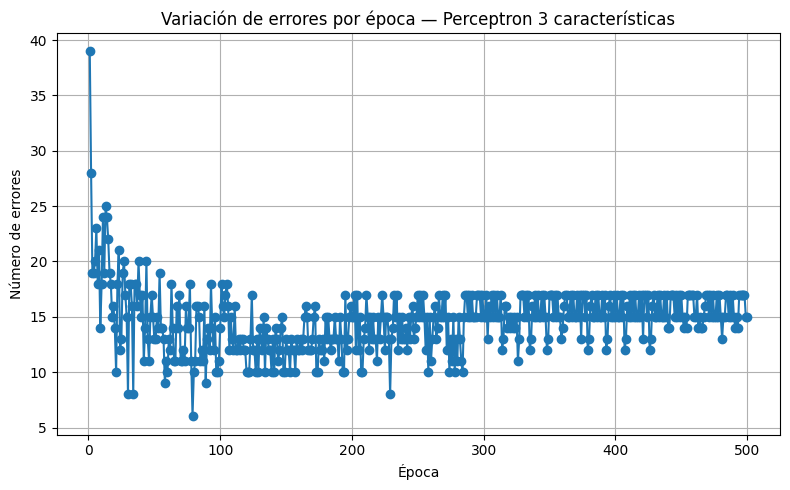

In [43]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(ppn3.errors_) + 1), ppn3.errors_, marker='o')
plt.xlabel('Época')
plt.ylabel('Número de errores')
plt.title('Variación de errores por época — Perceptron 3 características')
plt.grid(True)
plt.tight_layout()
plt.show()


### 6.5.2 Variabilidad de los hiperparámetros (b, w₁, w₂, w₃) por época


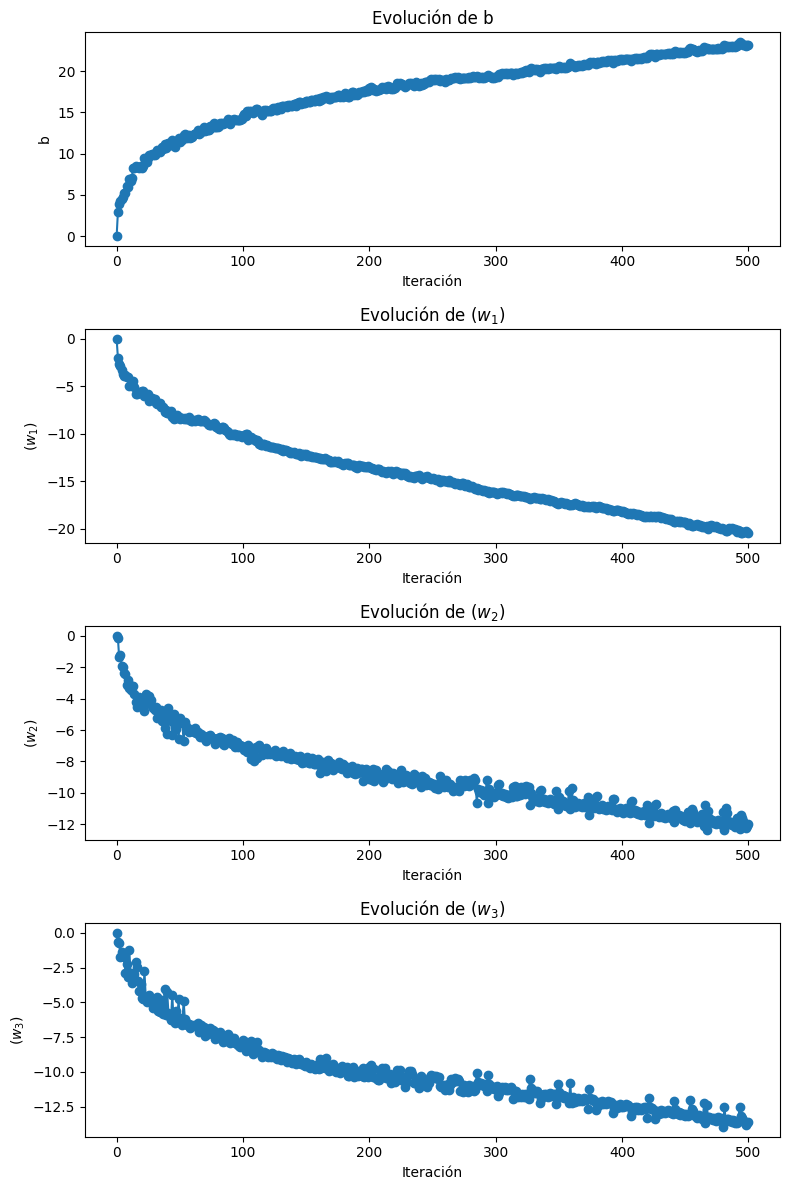

In [44]:
# Lista de etiquetas para los gráficos (4 parámetros: b, w1, w2, w3)
labels3 = ['b', '($w_1$)', '($w_2$)', '($w_3$)']

# Crear cuatro subgráficos
fig, axs = plt.subplots(len(labels3), 1, figsize=(8, 12))

# Iterar sobre cada etiqueta y crear un gráfico correspondiente
for i, label in enumerate(labels3):
    # Extraer la serie temporal para el parámetro actual
    series = [weights[i] for weights in ppn3.w_historical]

    # Graficar la serie temporal
    axs[i].plot(range(len(ppn3.w_historical)), series, marker='o')
    axs[i].set_title(f'Evolución de {label}')
    axs[i].set_xlabel('Iteración')
    axs[i].set_ylabel(label)

# Ajustar espaciado entre subgráficos
plt.tight_layout()

# Mostrar los gráficos
plt.show()


### 6.5.3 Plano de separación INICIAL sobre la dispersión 3D

Con los **pesos aleatorios iniciales** (antes del entrenamiento), el plano de separación no discrimina bien las clases.


In [53]:
import plotly.graph_objs as go
import numpy as np

# Pesos INICIALES (aleatorios, antes de entrenar)
b_i  = float(ppn3.w_historical[0][0])
w1_i = float(ppn3.w_historical[0][1])
w2_i = float(ppn3.w_historical[0][2])
w3_i = float(ppn3.w_historical[0][3])

# Evitar división por cero: si w3 es muy pequeño, usar un epsilon
eps = 1e-8
if abs(w3_i) < eps:
    w3_i = np.sign(w3_i) * eps if w3_i != 0 else eps

# Crear malla para el plano inicial
x1_range = np.linspace(X3[:, 0].min() - 1, X3[:, 0].max() + 1, 15)
x2_range = np.linspace(X3[:, 1].min() - 1, X3[:, 1].max() + 1, 15)
x1_m, x2_m = np.meshgrid(x1_range, x2_range)  # shape (len(x2), len(x1))

# Calcular z y limpiar no finitos
x3_plane_init = (-w1_i * x1_m - w2_i * x2_m - b_i) / w3_i
x3_plane_init = np.nan_to_num(x3_plane_init, nan=np.nanmean(X3[:, 2]),
                              posinf=np.max(X3[:, 2]), neginf=np.min(X3[:, 2]))
x3_plane_init = np.clip(x3_plane_init, X3[:, 2].min() - 5, X3[:, 2].max() + 5)

fig_init3d = go.Figure()

# Puntos de datos
color_map = {0: 'blue', 1: 'orange'}
cls_name_map = {0: 'Falso', 1: 'Verdadero'}
for cls_val in [0, 1]:
    mask = (y3 == cls_val)
    fig_init3d.add_trace(go.Scatter3d(
        x=X3[mask, 0], y=X3[mask, 1], z=X3[mask, 2],
        mode='markers',
        marker=dict(size=4, color=color_map[cls_val], opacity=0.8),
        name=cls_name_map[cls_val]
    ))

# Usar la malla (x1_m, x2_m) para los ejes del Surface (coincide con la forma de z)
fig_init3d.add_trace(go.Surface(
    x=x1_m,
    y=x2_m,
    z=x3_plane_init,
    opacity=0.4,
    colorscale='Reds',
    showscale=False,
    name='Plano inicial'
))

fig_init3d.update_layout(
    scene=dict(
        xaxis=dict(title=best_features_3[0].capitalize()),
        yaxis=dict(title=best_features_3[1].capitalize()),
        zaxis=dict(title=best_features_3[2].capitalize()),
    ),
    title='Plano de separación INICIAL (pesos aleatorios) — Perceptron 3 características'
)
fig_init3d.show()

### 6.5.4 Plano de separación FINAL sobre la dispersión 3D (convergencia)

Con los **pesos finales** (después del entrenamiento), el plano de separación muestra la convergencia del Perceptron.


In [46]:

# Pesos FINALES (después del entrenamiento)
b_f  = float(ppn3.w_historical[-1][0])
w1_f = float(ppn3.w_historical[-1][1])
w2_f = float(ppn3.w_historical[-1][2])
w3_f = float(ppn3.w_historical[-1][3])

print("Pesos finales → b:", b_f, " w1:", w1_f, " w2:", w2_f, " w3:", w3_f)

# Evitar división por cero para w3
eps = 1e-8
if abs(w3_f) < eps:
    w3_f = np.sign(w3_f) * eps if w3_f != 0 else eps

# Malla para el plano final (reutilizamos x1_range, x2_range, x1_m, x2_m de la celda anterior)
x3_plane_final = (-w1_f * x1_m - w2_f * x2_m - b_f) / w3_f
# Reemplazar no finitos y recortar al rango de los datos
x3_plane_final = np.nan_to_num(x3_plane_final, nan=np.nanmean(X3[:,2]), posinf=np.max(X3[:,2]), neginf=np.min(X3[:,2]))
x3_plane_final = np.clip(x3_plane_final, X3[:, 2].min() - 5, X3[:, 2].max() + 5)

fig_final3d = go.Figure()

# Puntos de datos
for cls_val in [0, 1]:
    mask = (y3 == cls_val)
    fig_final3d.add_trace(go.Scatter3d(
        x=X3[mask, 0], y=X3[mask, 1], z=X3[mask, 2],
        mode='markers',
        marker=dict(size=4, color=color_map[cls_val], opacity=0.8),
        name=cls_name_map[cls_val]
    ))

# Plano final: pasar x1_range (1D), x2_range (1D) y z (2D)
fig_final3d.add_trace(go.Surface(
    x=x1_range, y=x2_range, z=x3_plane_final,
    opacity=0.4,
    colorscale='Greens',
    showscale=False,
    name='Plano final'
))

fig_final3d.update_layout(
    scene=dict(
        xaxis=dict(title=best_features_3[0].capitalize()),
        yaxis=dict(title=best_features_3[1].capitalize()),
        zaxis=dict(title=best_features_3[2].capitalize()),
    ),
    title='Plano de separación FINAL (convergencia) — Perceptron 3 características'
)
fig_final3d.show()


Pesos finales → b: 23.216243453636697  w1: -20.4314533041379  w2: -11.979099717521489  w3: -13.576510086219937



---

## Conclusiones — Punto 6: Perceptron con tres características (`variance`, `skewness`, `curtosis`)

### Mejora respecto al modelo de 2 características
Al incluir `curtosis` como tercera dimensión, el Perceptron dispone de mayor información para construir un hiperplano de separación. Los errores por época **convergen más rápido y a un valor menor** en comparación con el modelo 2D, aunque el problema sigue sin ser perfectamente linealmente separable.

### Evolución de hiperparámetros
- Los cuatro parámetros (**b**, **w₁**, **w₂**, **w₃**) muestran mayor estabilidad a partir de las primeras épocas en comparación con el modelo 2D.  
- **w₃** (asociado a `curtosis`) adquiere valores relevantes, confirmando que esta característica aporta poder discriminativo real.

### Planos de separación (3D interactivo)
- El **plano inicial** (pesos aleatorios) no discrimina las clases y corta arbitrariamente la nube de puntos.  
- El **plano final** (pesos convergidos) logra una separación notablemente mejor, orientándose de forma que deja la mayoría de los puntos de cada clase a un lado del plano.


**Conclusión general:** Agregar `curtosis` como tercera característica mejora la capacidad del Perceptron para separar billetes falsos de verdaderos, reduciendo el error de clasificación y produciendo un hiperplano de decisión más representativo. 
